Material for the book Probability and Statistics for Data Science. A free preprint, videos, code, slides and solutions to exercises are available at https://www.ps4ds.net/

Comparison between the sample correlation coefficient and the Spearman rank correlation coefficient.\
Topics and relevant videos: [Overview of correlation](https://www.youtube.com/watch?v=LMKnAVH-J3U), [correlation and covariance](https://www.youtube.com/watch?v=LMKnAVH-J3U)

Author: Carlos Fernandez-Granda\
Data source:https://www.gapminder.org/

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, rankdata

# Load the dictionary of NumPy arrays
loaded_data = np.load('../data/spearman_correlation.npz')
gdp = loaded_data['GDP']
life_exp = loaded_data['LifeExpectancy']
loaded_data.close()

In [3]:
# Compute sample correlation coefficient and Spearman rank correlation coefficient
corr,_ = pearsonr(gdp, life_exp)
spearman_corr,_ = spearmanr(gdp, life_exp)
print(f"Sample correlation coefficient: {corr:.3f}")
print(f"Spearman rank correlation coefficient: {spearman_corr:.3f}")

Sample correlation coefficient: 0.679
Spearman rank correlation coefficient: 0.857


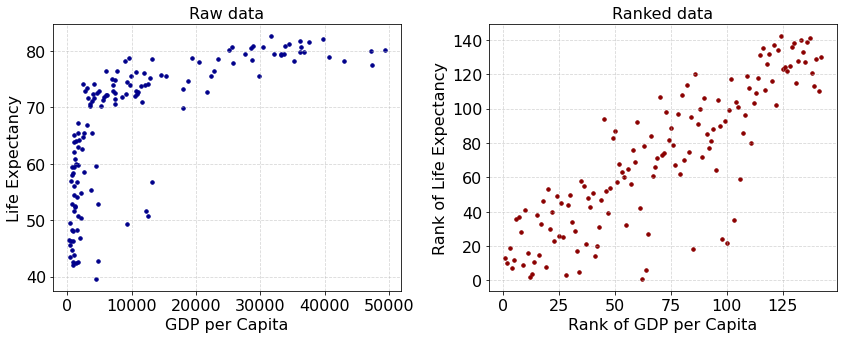

In [9]:
# Compute the ranks used for Spearman correlation explicitly
# scipy.stats.rankdata computes numerical ranks (1-based by default)
gdp_ranks = rankdata(gdp)
life_exp_ranks = rankdata(life_exp)

font_size = 16  # Single parameter to control all font sizes

# Set global matplotlib font sizes
plt.rcParams.update({
    'font.size': font_size,          # Default text size
    'axes.labelsize': font_size,     # x and y axis labels
    'axes.titlesize': font_size,     # Subplot titles
    'xtick.labelsize': font_size,    # x tick labels
    'ytick.labelsize': font_size     # y tick labels
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

msize=12
ax1.scatter(gdp, life_exp,  color='darkblue',s=msize)
ax1.set_title(f"Raw data")
ax1.set_xlabel("GDP per Capita")
ax1.set_ylabel("Life Expectancy")
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot 4: Ranked Data Scatterplot (Spearman)
ax2.scatter(gdp_ranks, life_exp_ranks, color='darkred',s=msize)
ax2.set_title(f"Ranked data")
ax2.set_xlabel("Rank of GDP per Capita")
ax2.set_ylabel("Rank of Life Expectancy")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()